# Custom Data Preprocessing for JPF-WCA Dataset

This script demonstrates how we perform our own data transformations for our own custom dataset. We implement `make_map_fn` functions to extract answers and format each example according to the required structure. The steps include:

- Loading the dataset that we created manually.
- Processing each example using a custom mapping function:
    - Constructing a data item with the fields: `data_source`, `prompt`, `ability`, `reward_model`, and `extra_info`.
- Saving the processed dataset in parquet format locally.
- Copying the local data to HDFS.

You can modify these functions to suit your own dataset or task requirements.


In [2]:
import pandas as pd

df = pd.read_parquet("eval-instruct-v2.parquet")


In [3]:
df

,problem,example_indices,examples,question,answer_index,answer_constants,answer_solution,variable_mapping
0,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,2,(declare-const out_2 Int)\n(declare-const l_1 ...,(assert ( < l_1 out_2)),"{'get0': None, 'get1': None, 'in0': 'out_2', '..."
1,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,3,(declare-const local_2 Int)\n(declare-const w_...,(assert (and ( < local_2 i_1) ( < w_3 loca...,"{'get0': None, 'get1': None, 'in0': 'local_2',..."
2,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,4,(declare-const res_2 Int)\n(declare-const a_4 ...,(assert (and (and ( < res_2 d_1) ( < d_1 a...,"{'get0': None, 'get1': None, 'in0': 'res_2', '..."
3,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,5,(declare-const out_4 Int)\n(declare-const y_2 ...,(assert (and (and (and ( < out_4 w_3) ( < ...,"{'get0': None, 'get1': None, 'in0': 'out_4', '..."
4,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,6,(declare-const g_3 Int)\n(declare-const res_5 ...,(assert (and (and (and (and ( < res_5 i_4) ...,"{'get0': None, 'get1': None, 'in0': 'res_5', '..."
...,...,...,...,...,...,...,...,...
13745,ComplexHalfEqual,"[23, 24, 25, 26, 27]","[{'index': 23, 'solution': '(assert (and (and ...",<|im_start|>system\n You are a helpful assi...,29,(declare-const j_3 Int)\n(declare-const local_...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'z_28', 'i..."
13746,ComplexHalfEqual,"[23, 24, 25, 26, 27]","[{'index': 23, 'solution': '(assert (and (and ...",<|im_start|>system\n You are a helpful assi...,30,(declare-const l_3 Int)\n(declare-const n_16 I...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'arg_29', ..."
13747,ComplexHalfEqual,"[24, 25, 26, 27, 28]","[{'index': 24, 'solution': '(assert (and (and ...",<|im_start|>system\n You are a helpful assi...,29,(declare-const i_3 Int)\n(declare-const arg_16...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'i_28', 'i..."
13748,ComplexHalfEqual,"[24, 25, 26, 27, 28]","[{'index': 24, 'solution': '(assert (and (and ...",<|im_start|>system\n You are a helpful assi...,30,(declare-const n_3 Int)\n(declare-const u_16 I...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'global_29..."


In [4]:
df.loc[0]

problem                                           SimpleAscendingLast
example_indices                                                   [1]
examples                             [{'index': 1, 'solution': None}]
question            <|im_start|>system\n    You are a helpful assi...
answer_index                                                        2
answer_constants    (declare-const out_2 Int)\n(declare-const l_1 ...
answer_solution                             (assert  ( <  l_1 out_2))
variable_mapping    {'get0': None, 'get1': None, 'in0': 'out_2', '...
Name: 0, dtype: object

In [6]:
# Check if any row the examples array's solution is all None
df["examples"].apply(lambda x: all([e["solution"] is None for e in x])).any()

True

In [7]:
# Show all the rows that have examples with all None solutions
df[df["examples"].apply(lambda x: all([e["solution"] is None for e in x]))]

,problem,example_indices,examples,question,answer_index,answer_constants,answer_solution,variable_mapping
0,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,2,(declare-const out_2 Int)\n(declare-const l_1 ...,(assert ( < l_1 out_2)),"{'get0': None, 'get1': None, 'in0': 'out_2', '..."
1,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,3,(declare-const local_2 Int)\n(declare-const w_...,(assert (and ( < local_2 i_1) ( < w_3 loca...,"{'get0': None, 'get1': None, 'in0': 'local_2',..."
2,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,4,(declare-const res_2 Int)\n(declare-const a_4 ...,(assert (and (and ( < res_2 d_1) ( < d_1 a...,"{'get0': None, 'get1': None, 'in0': 'res_2', '..."
3,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,5,(declare-const out_4 Int)\n(declare-const y_2 ...,(assert (and (and (and ( < out_4 w_3) ( < ...,"{'get0': None, 'get1': None, 'in0': 'out_4', '..."
4,SimpleAscendingLast,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,6,(declare-const g_3 Int)\n(declare-const res_5 ...,(assert (and (and (and (and ( < res_5 i_4) ...,"{'get0': None, 'get1': None, 'in0': 'res_5', '..."
...,...,...,...,...,...,...,...,...
13125,ComplexHalfEqual,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,2,(declare-const z_2 Int)\n(declare-const h_1 Int),(assert ( = z_2 h_1)),"{'get0': None, 'get1': None, 'in0': 'z_2', 'in..."
13126,ComplexHalfEqual,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,3,(declare-const o_2 Int)\n(declare-const o_3 In...,(assert (and ( = o_2 b_1) ( < b_1 o_3))),"{'get0': None, 'get1': None, 'in0': 'o_2', 'in..."
13127,ComplexHalfEqual,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,4,(declare-const res_2 Int)\n(declare-const c_4 ...,(assert (and (and ( = res_2 res_1) ( = res...,"{'get0': None, 'get1': None, 'in0': 'res_2', '..."
13128,ComplexHalfEqual,[1],"[{'index': 1, 'solution': None}]",<|im_start|>system\n You are a helpful assi...,5,(declare-const h_4 Int)\n(declare-const res_2 ...,(assert (and (and (and ( = h_4 y_3) ( = y_...,"{'get0': None, 'get1': None, 'in0': 'h_4', 'in..."


In [8]:
df.drop(df[df["examples"].apply(lambda x: all([e["solution"] is None for e in x]))].index, inplace=True)

In [14]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")

# Remove all the question that are greater than 1.8k tokens
print("Before filtering", len(df))

df.drop(df[df["question"].apply(lambda x: len(tokenizer(x)["input_ids"])) > 1000].index, inplace=True)

print("After filtering", len(df))

Before filtering 10370
After filtering 7326


In [18]:
def make_map_fn(split):
    def process_fn(row):
        data = {
            "data_source": "dannkoh/ConStruct-Base",
            "prompt": [{"role": "user", "content": row["question"]}],
            "ability": "generalisation",
            "reward_model": {"style": "rule", "ground_truth": row["answer_solution"]},
            "extra_info": {
                "answer_constants": row["answer_constants"],
                "variable_mapping": row["variable_mapping"],
                "answer_index": row["answer_index"],
                "example_indices": row["example_indices"],
            },
        }
        return data

    return process_fn

In [19]:
# Split the data into 2 parts: one for training and one for testing (75% training, 25% testing)
train = df.sample(frac=0.75, random_state=0)
test = df.drop(train.index)

train_dataset = pd.DataFrame(train.apply(make_map_fn("train"), axis=1).tolist())
test_dataset = pd.DataFrame(test.apply(make_map_fn("test"), axis=1).tolist())

In [20]:
train_dataset.to_parquet("train-instruct-v2.parquet")
test_dataset.to_parquet("test-instruct-v2.parquet")

In [21]:
train_dataset

,data_source,prompt,ability,reward_model,extra_info
0,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const j_9 Int) ...
1,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const r_2 Int) ...
2,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const s_3 Int) ...
3,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const res_12 In...
4,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const global_20...
...,...,...,...,...,...
5489,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const l_9 Int) ...
5490,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const global_3 ...
5491,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const tmp_6 Int...
5492,dannkoh/ConStruct-Base,"[{'role': 'user', 'content': '<|im_start|>syst...",generalisation,"{'style': 'rule', 'ground_truth': '(assert (an...",{'answer_constants': '(declare-const b_13 Int)...


In [12]:
# max, min, mean prompt token length of qwen tokenizer

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")

print("Max prompt token length:", df["question"].apply(tokenizer.tokenize).apply(len).max())
print("Min prompt token length:", df["question"].apply(tokenizer.tokenize).apply(len).min())
print("Mean prompt token length:", df["question"].apply(tokenizer.tokenize).apply(len).mean())

Max prompt token length: 1800


KeyboardInterrupt: 

count    10370.000000
mean       815.280521
std        388.323728
min        336.000000
25%        489.000000
50%        707.000000
75%       1068.000000
max       1800.000000
Name: token_length, dtype: float64

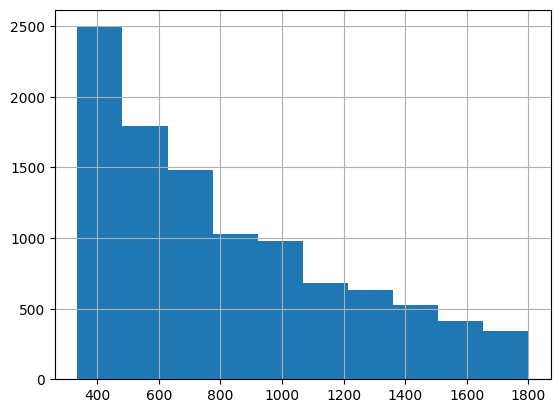

In [10]:
temp = df.copy()
temp["token_length"] = df["question"].apply(tokenizer.tokenize).apply(len)

temp["token_length"].hist()

temp["token_length"].describe()

In [11]:
# get tokenized prompt length distribution

distribution = df["question"].apply(tokenizer.tokenize).apply(len).value_counts().sort_index()

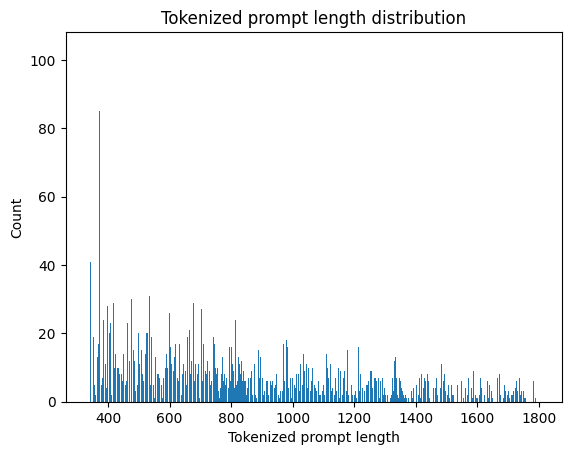

1424.0

In [13]:
# Plot distribution and take a subset of the data to use.
import matplotlib.pyplot as plt

plt.bar(distribution.index, distribution.values)
plt.xlabel("Tokenized prompt length")
plt.ylabel("Count")
plt.title("Tokenized prompt length distribution")
plt.show()

# Take the 90th percentile of the data
df["question"].apply(tokenizer.tokenize).apply(len).quantile(0.9)